In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

np.random.seed(42)
print('Setup complete. NumPy', np.__version__)

Setup complete. NumPy 2.1.3


In [7]:
rolls= np.random.randint(1, 7, size=100_000)
p_even = (rolls % 2 == 0).mean()
p_gt4  = (rolls > 4).mean()
print('P(even) ~', round(p_even, 3), ' (true 0.5)')
print('P(>4)   ~', round(p_gt4, 3),  ' (true 0.333)')

P(even) ~ 0.501  (true 0.5)
P(>4)   ~ 0.333  (true 0.333)


In [9]:
p_1 = (rolls == 1).mean()
p_2 = (rolls == 2).mean()
p_1_or_2 = (np.isin(rolls, [1, 2])).mean()
print('P(1) + P(2) =', round(p_1 + p_2, 3))
print('P(1 or 2)   =', round(p_1_or_2, 3), ' -> they match')

P(1) + P(2) = 0.333
P(1 or 2)   = 0.333  -> they match


#### 🧪 LAB EXERCISE 1 — Probability by simulation

Simulate flipping **two coins** 100,000 times (`0 = tails, 1 = heads`):
1. Estimate `P(both heads)`.
2. Estimate `P(at least one head)`.
3. Check the addition idea: does `P(0 heads) + P(1 head) + P(2 heads)` sum to 1?

In [16]:
flips = np.random.randint(0, 2, size=(100_000, 2))   # 100k pairs of flips
heads = flips.sum(axis=1)   # number of heads in each pair: 0, 1 or 2

# 1. P(both heads)  -> heads == 2
# YOUR CODE HERE
both_heads = (heads == 2).mean()
print("1. P(both heads):",both_heads)

# 2. P(at least one head)  -> heads >= 1
# YOUR CODE HERE
at_least_one_head = (heads >= 1).mean()
print("2. P(at least one head):",at_least_one_head)
# 3. Do P(0) + P(1) + P(2) sum to 1?
# YOUR CODE HERE
p_0 = (heads == 0).mean()
p_1 = (heads == 1).mean()
p_2 = (heads == 2).mean()
print("3. P(0) + P(1) + P(2) =", p_0 + p_1 + p_2)

1. P(both heads): 0.25034
2. P(at least one head): 0.74948
3. P(0) + P(1) + P(2) = 1.0


In [18]:
rolls = np.random.randint(1, 7, size=100_000)
even = rolls[rolls % 2 == 0]
p_6_given_even = (even == 6).mean()
print('P(6 | even) :', round(p_6_given_even, 3), ' (true 1/3)')

P(6 | even) : 0.333  (true 1/3)


In [30]:
A = rolls > 3
B = rolls % 2 == 0
p_A= A.mean()
p_A_given_B = A[B].mean()
print('P(A)=', round(p_A, 3))
print('P(A | B)=', round(p_A_given_B, 3))
print('Independent?', np.isclose(p_A, p_A_given_B, atol=0.02))

P(A)= 0.499
P(A | B)= 0.665
Independent? False


#### 🧪 LAB EXERCISE 2 — Conditional probability

Using fresh dice rolls:
1. Estimate `P(roll is odd | roll < 4)`.
2. Estimate `P(roll < 4)` overall.
3. Are the events 'roll is odd' and 'roll < 4' independent? Compare `P(odd|<4)` with `P(odd)`.

In [24]:
rolls = np.random.randint(1, 7, size=100_000)

# 1. P(odd | roll < 4)  -> condition on rolls < 4, then check odd
# YOUR CODE HERE
a=rolls < 4
b=rolls % 2!=0
p_a=a.mean()
p_b_given_a=b[a].mean()
print("P(odd|roll<4):",p_b_given_a)

# 2. P(roll < 4)
# YOUR CODE HERE
print("rolls <4:",p_a)

# 3. Compare P(odd | <4) with P(odd) overall — independent?
# YOUR CODE HERE
p_b=b.mean()
print('Independent?', np.isclose(p_b_given_a,p_b, atol=0.02))

P(odd|roll<4): 0.6670524383430442
rolls <4: 0.50116
Independent? False


In [25]:
p_disease   = 0.01
p_pos_given_D  = 0.99
p_pos_given_nD = 0.01

p_pos = p_pos_given_D * p_disease + p_pos_given_nD * (1 - p_disease)
p_D_given_pos = (p_pos_given_D * p_disease) / p_pos
print('P(sick | positive test) =', round(p_D_given_pos, 3))
print('-> only ~50%, because the disease is rare (base-rate effect)')

P(sick | positive test) = 0.5
-> only ~50%, because the disease is rare (base-rate effect)


In [26]:
N = 1_000_000
has_disease = np.random.rand(N) < p_disease
tests_pos = np.where(has_disease,
                     np.random.rand(N) < p_pos_given_D,
                     np.random.rand(N) < p_pos_given_nD)

among_positive = has_disease[tests_pos]
print('Simulated P(sick | positive) =', round(among_positive.mean(), 3))

Simulated P(sick | positive) = 0.498


#### 🧪 LAB EXERCISE 3 — A Bayes scenario (spam filter)

A spam filter: **20%** of email is spam. The word *"free"* appears in **60%** of spam but only **5%** of real email. An email contains *"free"* — what's `P(spam | "free")`?
1. Write down the prior, likelihood and false-positive rate.
2. Compute `P("free")` with the total-probability rule.
3. Apply Bayes to get `P(spam | "free")`.

In [29]:
# 1. priors / likelihoods
p_spam = 0.20
p_free_given_spam = 0.60
p_free_given_ham  = 0.05

# 2. P('free') via total probability
# YOUR CODE HERE
p_ham = 1 - p_spam
p_free = (p_free_given_spam * p_spam) + (p_free_given_ham * p_ham)
print("P('free') = ",round(p_free, 3))

# 3. Bayes: P(spam | 'free')
# YOUR CODE HERE
p_spam_given_free = (p_free_given_spam * p_spam) / p_free
print("P(spam | 'free')=",round(p_spam_given_free, 3))

P('free') =  0.16
P(spam | 'free')= 0.75


In [31]:
bern = stats.bernoulli(p=0.3).rvs(size=10_000)
print('Bernoulli(0.3) mean ~', round(bern.mean(), 3), '(true 0.3)')

pois = stats.poisson(mu=4).rvs(size=10_000)
print('Poisson(4) mean ~', round(pois.mean(), 3), '(true 4)')

Bernoulli(0.3) mean ~ 0.298 (true 0.3)
Poisson(4) mean ~ 4.003 (true 4)


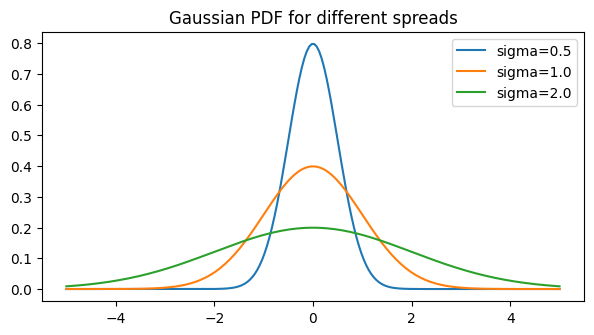

In [34]:
x = np.linspace(-5, 5, 200)
fig, ax = plt.subplots(figsize=(7, 3.5))
for sigma in [0.5, 1.0, 2.0]:
    ax.plot(x, stats.norm(0, sigma).pdf(x), label=f'sigma={sigma}')
ax.set_title('Gaussian PDF for different spreads');
ax.legend();
plt.show()

#### 🧪 LAB EXERCISE 4 — Simulate & plot distributions

1. Draw 10,000 samples from a **Poisson** with `mu=2` and print the sample mean.
2. Plot a **histogram** of those samples.
3. Plot the **Gaussian PDF** for `mu=0` with two different sigmas on one chart and observe how the spread changes the curve.

Poisson(2) mean ~ 2.004 (true 2)


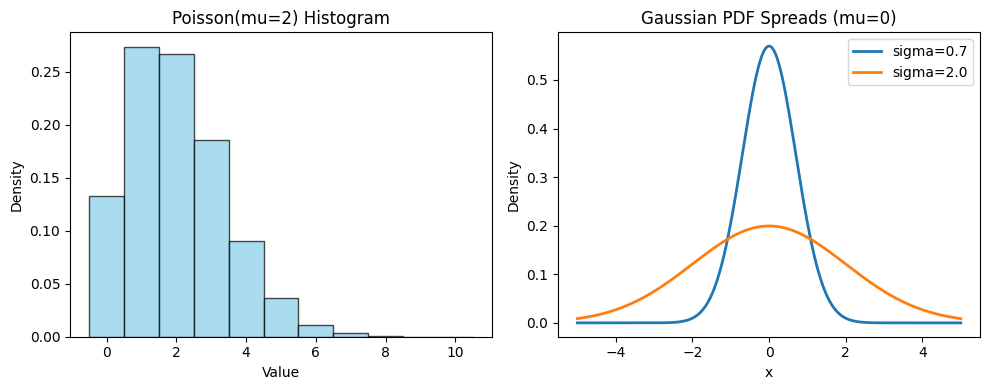

In [36]:
# 1. Poisson(mu=2) samples + mean
# YOUR CODE HERE
pois = stats.poisson(mu=2).rvs(size=10_000)
print('Poisson(2) mean ~', round(pois.mean(), 3), '(true 2)')
# 2. histogram of the samples  (plt.hist(...))
# YOUR CODE HERE
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
bins = np.arange(0, np.max(pois) + 2) - 0.5
plt.hist(pois, bins=bins, density=True, color='skyblue', edgecolor='black', alpha=0.7)
plt.title('Poisson(mu=2) Histogram')
plt.xlabel('Value')
plt.ylabel('Density')

# 3. Gaussian PDF for two sigmas on one plot
# YOUR CODE HERE
plt.subplot(1, 2, 2)
x = np.linspace(-5, 5, 200)
for sigma in [0.7, 2.0]:
    pdf_values = stats.norm(0, sigma).pdf(x)
    plt.plot(x, pdf_values, label=f'sigma={sigma}', linewidth=2)
plt.title('Gaussian PDF Spreads (mu=0)')
plt.xlabel('x')
plt.ylabel('Density')
plt.legend()
plt.tight_layout()
plt.show()


In [37]:
from scipy.stats import entropy

fair   = [0.5, 0.5]
biased = [0.9, 0.1]
certain= [1.0, 0.0]

print('Entropy fair coin   :', round(entropy(fair, base=2), 3), 'bits')
print('Entropy biased coin :', round(entropy(biased, base=2), 3), 'bits')
print('Entropy certain     :', round(entropy(certain, base=2), 3), 'bits')

Entropy fair coin   : 1.0 bits
Entropy biased coin : 0.469 bits
Entropy certain     : 0.0 bits


In [38]:
P = np.array([0.5, 0.5])
Q = np.array([0.9, 0.1])

print('D(P || Q) =', round(entropy(P, Q, base=2), 3), 'bits')
print('D(P || P) =', round(entropy(P, P, base=2), 3), '-> zero (identical)')
print('Note: D(P||Q) != D(Q||P)  ->', round(entropy(Q, P, base=2), 3), '(not symmetric)')

D(P || Q) = 0.737 bits
D(P || P) = 0.0 -> zero (identical)
Note: D(P||Q) != D(Q||P)  -> 0.531 (not symmetric)


In [39]:
from sklearn.feature_selection import mutual_info_classif
from sklearn.datasets import load_iris

iris = load_iris()
mi = mutual_info_classif(iris.data, iris.target, random_state=0)
for name, score in sorted(zip(iris.feature_names, mi), key=lambda t: -t[1]):
    print(f'{score:.3f}  {name}')
print('-> higher MI = the feature tells us more about the class')

0.990  petal length (cm)
0.975  petal width (cm)
0.474  sepal length (cm)
0.286  sepal width (cm)
-> higher MI = the feature tells us more about the class


#### 🧪 LAB EXERCISE 5 — Information theory

1. Compute the entropy (in bits) of a fair **4-sided die** and a fair **6-sided die**. Which is more uncertain?
2. Compute the KL divergence `D(P || Q)` for `P = [0.7, 0.3]` and `Q = [0.5, 0.5]`.
3. From the iris MI scores above, name the **most** and **least** informative feature.

In [43]:
# 1. Entropy of a fair 4-sided and 6-sided die (use base=2)
# hint: a fair n-sided die is [1/n]*n
# YOUR CODE HERE
p_4 = [1/4] * 4
p_6 = [1/6] * 6
ent_4 = entropy(p_4, base=2)
ent_6 = entropy(p_6, base=2)
print('Entropy of 4-sided die:', round(ent_4, 3), 'bits')
print('Entropy of 6-sided die:', round(ent_6, 3), 'bits')

# 2. KL divergence D(P || Q)
P = np.array([0.7, 0.3]); Q = np.array([0.5, 0.5])
# YOUR CODE HERE
kl_div = entropy(P, Q, base=2)
print('D(P || Q) =', round(kl_div, 3), 'bits')

# 3. Most / least informative iris feature (from 5C)
# Most informative: ...   Least informative: ...
most_idx = np.argmax(mi)
least_idx = np.argmin(mi)
print('Most informative feature:', iris.feature_names[most_idx])
print('Least informative feature:', iris.feature_names[least_idx])

Entropy of 4-sided die: 2.0 bits
Entropy of 6-sided die: 2.585 bits
D(P || Q) = 0.119 bits
Most informative feature: petal length (cm)
Least informative feature: sepal width (cm)
